# How to calculate the L2-norm of a field

**Step 1: Create FELiCSMesh, FELiCSSpace and Field**


Info     | FELiCSMesh.py          | __init__                   (line 75  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 83  ) : Mesh contains 513 nodes and 1024 elements


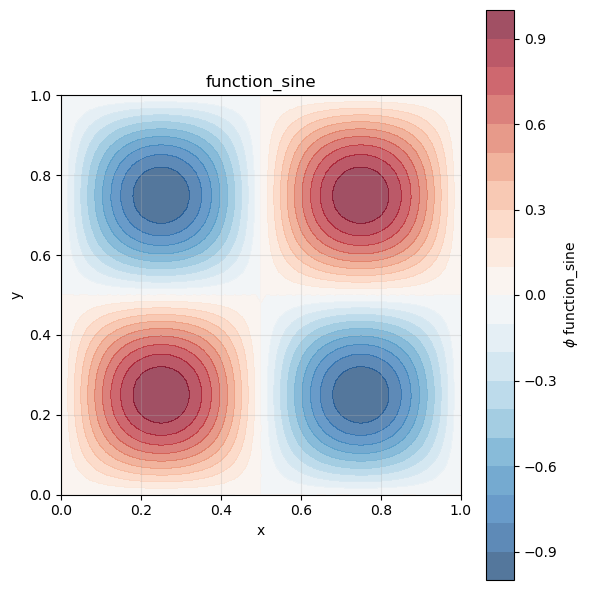

In [5]:
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh
from FELiCS.SpaceDisc.FEMSpaces  import createFunctionSpace
from FELiCS.Fields.Field         import Field
from FELiCS.IO.Reader            import Reader

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

scalarSpace = createFunctionSpace(mesh, degree=2, dim=1)

phi = Field(scalarSpace, mesh=mesh, name="function_sine")
phi.importData(Reader(),"input.h5")
phi.plot()


**Step 2: Calculate the L2-norm of a field**

Now we will calculate an integral quantity of our field. We will calculate the L2-norm of our field over the whole domain.

The L2-norm is defined as:
$$||\phi(\mathbf{x})||_{L^2} = \sqrt{\int_\Omega |\phi(\mathbf{x})|^2 \, d\Omega}$$

For this, the `Field` class has the method `calculateL2Norm()` which computes this integral over the entire mesh domain.


In [6]:
u_norm = phi.calculateL2Norm()

print(f"L2-norm of the field: {u_norm}")

L2-norm of the field: (0.49952523537468385+0j)
